In [16]:
import os
import json
import cv2
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from google.colab import drive

drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [17]:
PROJECT = os.path.abspath("/content/drive/MyDrive/DATASCI281")
os.chdir(PROJECT)

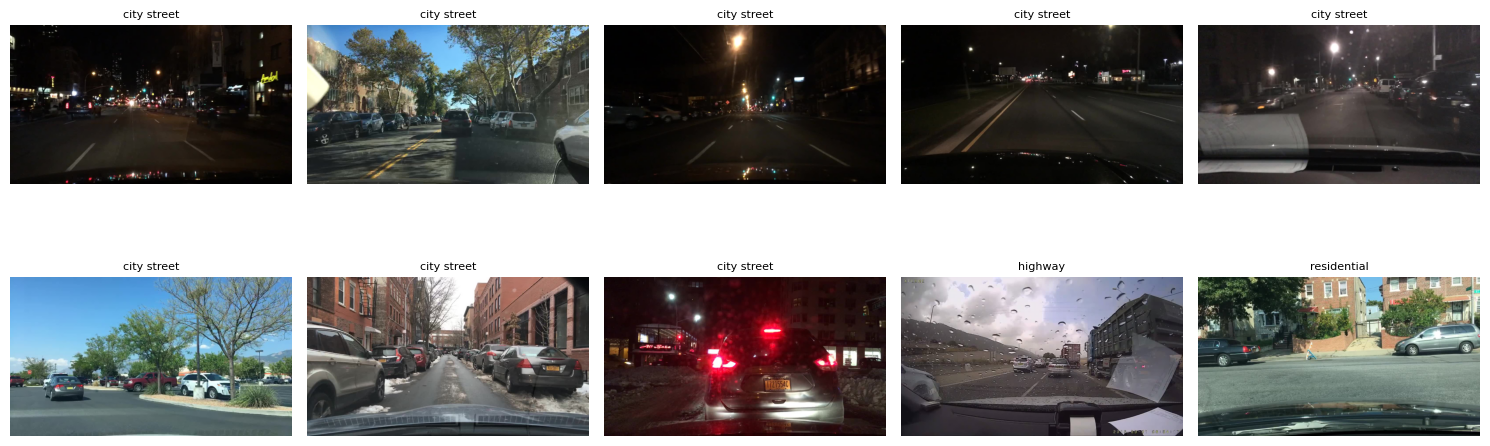

In [18]:
IMG_FOLDER = "sample1000/images/train"
LABEL_FOLDER = "sample1000/labels/train"

# Sort so image and label files stay aligned
img_files_train = sorted(os.listdir(IMG_FOLDER))
label_files_train = sorted(os.listdir(LABEL_FOLDER))

rng = np.random.default_rng()

# Sample indices
indices = rng.choice(len(img_files_train), size=10, replace=False)

img_sample = []
label_sample = []

fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for ax, idx in zip(axes.ravel(), indices):
    img_file = img_files_train[idx]
    label_file = label_files_train[idx]

    # Load image
    img = plt.imread(os.path.join(IMG_FOLDER, img_file))
    img_sample.append(img)

    # Load label
    with open(os.path.join(LABEL_FOLDER, label_file), "r", encoding="utf-8") as f:
        scene = json.load(f)["attributes"]["scene"]
        label_sample.append(scene)

    ax.imshow(img)
    ax.set_title(scene, fontsize=8)
    ax.axis("off")

plt.tight_layout()
plt.show()


In [19]:
print(img_sample[0].shape)

(720, 1280, 3)


In [20]:
def random_crop(image: np.ndarray, crop_size: tuple[int, int], rng=None) -> np.ndarray:
    """
    Randomly crop an image.

    Parameters
    ----------
    image : np.ndarray
        Image of shape (H, W, C).
    crop_size : tuple[int, int]
        Desired crop size as (crop_height, crop_width).
    rng : np.random.Generator, optional
        Random number generator. If None, a new default generator is used.

    Returns
    -------
    np.ndarray
        Cropped image of shape (crop_height, crop_width, C).
    """
    if rng is None:
        rng = np.random.default_rng()

    H, W = image.shape[:2]
    crop_h, crop_w = crop_size

    if crop_h > H or crop_w > W:
        raise ValueError(
            f"Crop size {(crop_h, crop_w)} exceeds image size {(H, W)}."
        )

    top = rng.integers(0, H - crop_h + 1)
    left = rng.integers(0, W - crop_w + 1)

    return image[top:top + crop_h, left:left + crop_w]

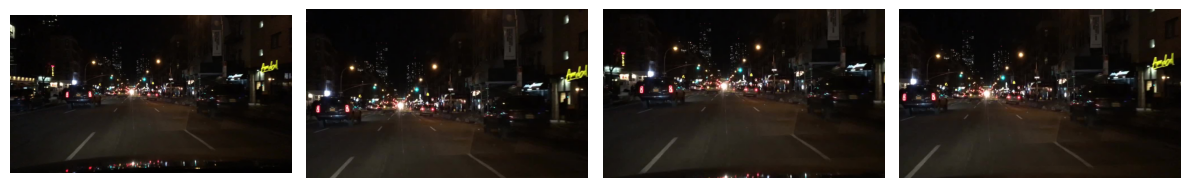

In [21]:
image = img_sample[0]

rng = np.random.default_rng(42)

crop1 = random_crop(image, (600, 1000), rng)
crop2 = random_crop(image, (600, 1000), rng)
crop3 = random_crop(image, (600, 1000), rng)

fig, axes = plt.subplots(1, 4, figsize=(12, 4))

for ax, img in zip(axes.ravel(), (image, crop1, crop2, crop3)):
    ax.imshow(img)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [22]:
def hough_orientation_histogram(
    image,
    bins=18,
    canny_low=50,
    canny_high=150,
    hough_threshold=50,
    min_line_length=30,
    max_line_gap=10,
    normalize=True,
    weight_by_length=True,
):
    """
    Computes a histogram of Hough line orientations.

    Parameters
    ----------
    image : ndarray
        Input image (grayscale or BGR).
    bins : int
        Number of orientation bins over [0, 180).
    normalize : bool
        Normalize histogram to sum to 1.
    weight_by_length : bool
        Weight each line by its length.

    Returns
    -------
    hist : ndarray
        Orientation histogram.
    angles : ndarray
        Angle of every detected line (degrees).
    lengths : ndarray
        Length of every detected line.
    """

    # Convert to grayscale if needed
    if len(image.shape) == 3:
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    else:
        gray = image.copy()

    # Edge detection
    edges = cv2.Canny(gray, canny_low, canny_high)

    # Detect line segments
    lines = cv2.HoughLinesP(
        edges,
        rho=1,
        theta=np.pi / 180,
        threshold=hough_threshold,
        minLineLength=min_line_length,
        maxLineGap=max_line_gap,
    )

    hist = np.zeros(bins, dtype=np.float32)

    if lines is None:
        return hist, np.array([]), np.array([])

    angles = []
    lengths = []

    for line in lines:
        x1, y1, x2, y2 = line[0]

        dx = x2 - x1
        dy = y2 - y1

        length = np.hypot(dx, dy)

        angle = np.degrees(np.arctan2(dy, dx))

        # Convert to [0,180)
        angle = angle % 180

        angles.append(angle)
        lengths.append(length)

        bin_index = int(angle / 180 * bins)
        bin_index = min(bin_index, bins - 1)

        if weight_by_length:
            hist[bin_index] += length
        else:
            hist[bin_index] += 1

    if normalize and hist.sum() > 0:
        hist /= hist.sum()

    return hist, np.array(angles), np.array(lengths)

In [23]:
hist, angles, lengths = hough_orientation_histogram(image)
print(hist)
print(hist.shape)

[0.31641102 0.00575327 0.         0.01803954 0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.05620912 0.         0.         0.08298493 0.5206021 ]
(18,)


In [37]:
def tsne_hough_visualization(
    arrays,
    labels=None,
    perplexity=30,
    random_state=0,
    pca_dim=16,
):
    """
    Compute Hough orientation histograms for a list of arrays and visualize with t-SNE.

    Parameters
    ----------
    arrays : list[np.ndarray]
        Input arrays/images.
    hough_orientation_histogram : callable
        Function returning a 1D histogram vector of fixed length.
    labels : array-like, optional
        Class labels for coloring points.
    perplexity : float
        t-SNE perplexity.
    random_state : int
        Random seed.
    pca_dim : int
        PCA dimension before t-SNE (set <= feature dimension).

    Returns
    -------
    embedding : (N, 2) ndarray
        2D t-SNE coordinates.
    features : (N, D) ndarray
        Histogram feature matrix.
    """

    n = len(arrays)
    if n == 0:
        raise ValueError("arrays is empty")

    # Compute first feature once to know dimensionality
    first, _, _ = hough_orientation_histogram(arrays[0])

    d = len(first)

    # Preallocate feature matrix
    features = np.empty((n, d), dtype=np.float32)
    features[0] = first

    # Fill remaining rows
    for i in range(1, n):
        hist, _, _ = hough_orientation_histogram(arrays[i])
        features[i] = hist

    # PCA -> t-SNE (faster and usually better)
    if pca_dim is not None and pca_dim < d:
        features_reduced = PCA(
            n_components=pca_dim,
            svd_solver="randomized",
            random_state=random_state,
        ).fit_transform(features)
    else:
        features_reduced = features

    tsne = TSNE(
        n_components=2,
        perplexity=min(perplexity, n - 1),
        init="pca",
        learning_rate="auto",
        method="barnes_hut",
        random_state=random_state,
    )

    embedding = tsne.fit_transform(features_reduced)

    # Plot
    plt.figure(figsize=(7, 6))
    if labels is None:
        plt.scatter(embedding[:, 0], embedding[:, 1], s=12, alpha=0.8)
    else:
        unique_labels = {label: i for i, label in enumerate(set(all_labels))}
        label_ids = [unique_labels[label] for label in all_labels]
        plt.scatter(
            embedding[:, 0],
            embedding[:, 1],
            c=label_ids,
            cmap="tab10",
            s=12,
            alpha=0.8,
        )

    plt.title("t-SNE of Hough Orientation Histograms")
    plt.xlabel("t-SNE 1")
    plt.ylabel("t-SNE 2")
    plt.tight_layout()
    plt.show()

    return embedding, features

In [35]:
def load_label(file):
    with open(file, "r", encoding="utf-8") as f:
        return json.load(f)["attributes"]["scene"]

all_images = [plt.imread(f"{IMG_FOLDER}/{file}") for file in img_files_train]
all_labels = [load_label(f"{LABEL_FOLDER}/{file}") for file in label_files_train]


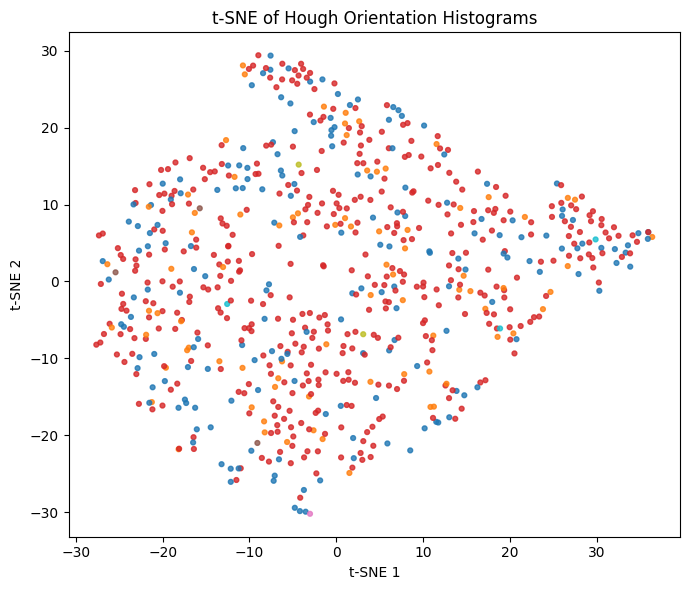

In [38]:
embedding, features = tsne_hough_visualization(all_images, labels=all_labels)